# Customer Churn Prediction

 Predict whether a customer will churn (leave) based on their account or service information

# import library

In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

# Load Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving CustomerChurn.csv to CustomerChurn.csv


In [9]:
df = pd.read_csv("CustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing rows
df = df.dropna().reset_index(drop=True)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df[["TotalCharges", "Churn"]].describe()

,TotalCharges,Churn
count,7032.000000,7032.000000
mean,2283.300441,0.265785
std,2266.771362,0.441782
min,18.800000,0.000000
25%,401.450000,0.000000
50%,1397.475000,0.000000
75%,3794.737500,1.000000
max,8684.800000,1.000000


# Churn Distribution

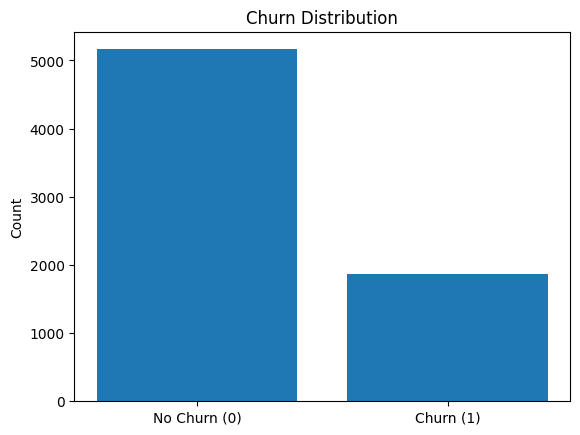

Churn rate: 0.26578498293515357


In [7]:
churn_counts = df["Churn"].value_counts().sort_index()

plt.figure()
plt.bar(["No Churn (0)", "Churn (1)"], churn_counts.values)
plt.title("Churn Distribution")
plt.ylabel("Count")
plt.show()

print("Churn rate:", df["Churn"].mean())

# Tenure vs Churn

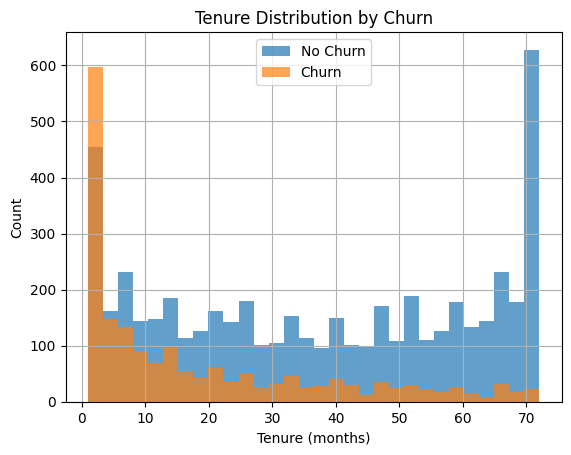

In [12]:
plt.figure()
df[df["Churn"] == 0]["tenure"].hist(bins=30, alpha=0.7, label="No Churn")
df[df["Churn"] == 1]["tenure"].hist(bins=30, alpha=0.7, label="Churn")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Feature

In [13]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical count:", len(categorical_features))

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical count: 15


# Train and Test Split

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Churn train distribution:\n", y_train.value_counts())

Train: (5625, 19) Test: (1407, 19)
Churn train distribution:
 Churn
0    4130
1    1495
Name: count, dtype: int64


# Preprocessing + Baseline Model Pipeline

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

clf

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=2000))])

# Train Baseline Model

In [16]:
clf.fit(X_train, y_train)
print("Baseline training done.")

Baseline training done.


# Baseline Evaluation

In [18]:
clf_weighted = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf_weighted.fit(X_train, y_train)

y_pred_w = clf_weighted.predict(X_test)
y_proba_w = clf_weighted.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_w))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_w))
print("\nClassification Report:\n", classification_report(y_test, y_pred_w))

Accuracy: 0.7320540156361052
ROC-AUC : 0.8316646908697475

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



# Confusion Matrix + ROC Curve

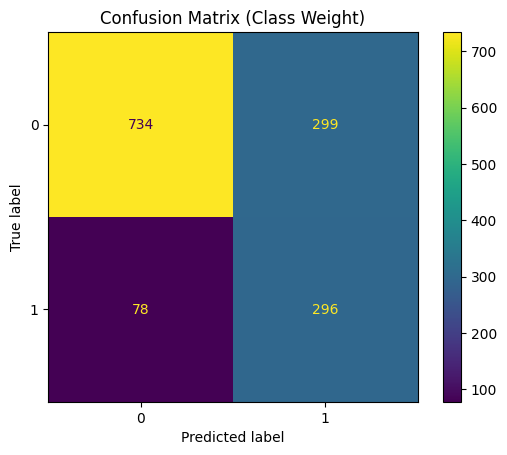

In [20]:
cm_w = confusion_matrix(y_test, y_pred_w)
ConfusionMatrixDisplay(confusion_matrix=cm_w).plot()
plt.title("Confusion Matrix (Class Weight)")
plt.show()

# Save Model

In [22]:
import joblib

joblib.dump(clf, "churn_pipeline.pkl")
print("Saved: churn_pipeline.pkl")

Saved: churn_pipeline.pkl


# Conclusion

This project successfully built a customer churn prediction model using Logistic Regression.

The baseline model achieved strong overall performance (ROC-AUC = 0.83), demonstrating good capability in distinguishing churn and non-churn customers. However, recall for churn detection was initially limited (52%).

By applying class weighting and threshold tuning, churn recall improved significantly to 79%, allowing the model to identify a much larger portion of at-risk customers. Although overall accuracy decreased slightly, this trade-off better aligns with business objectives focused on customer retention.

The results highlight that in churn prediction problems, improving recall for the minority class can be more valuable than maximizing overall accuracy.

Overall, this project demonstrates how machine learning can support data-driven retention strategies and revenue protection.

# Business Simulation

In [23]:
avg_monthly_revenue = 500000
retention_success_rate = 0.30

true_churn_detected = 296
customers_saved = int(true_churn_detected * retention_success_rate)

revenue_saved = customers_saved * avg_monthly_revenue

print("Estimated customers saved:", customers_saved)
print("Estimated monthly revenue saved (Rp):", revenue_saved)

Estimated customers saved: 88
Estimated monthly revenue saved (Rp): 44000000


## Business Impact Estimation

With improved churn recall (79%), the model can identify 296 at-risk customers.
Assuming a 30% retention success rate and an average monthly revenue of Rp 500,000 per customer,
the business could potentially retain approximately Rp 44+ million in monthly revenue.

This demonstrates how machine learning can directly support revenue protection strategies.